<a href="https://colab.research.google.com/github/ksshah/seed-and-scale/blob/main/wid_foastat_thirsty_crops_eda_20260819.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Thirsty Crops: FAOSTAT Completeness EDA
**WiD Datathon 2026, "What's Cooking?" | Grow track | Team notebook v1 (pre-kickoff)**

Purpose: before the Toolkit drops on Aug 18, verify how complete FAOSTAT data is for our four focus crops
(barley, hops, apples, maize/corn) so we know by kickoff whether the "Thirsty Crops" framing holds.

What "complete" means here (three checks, in order of importance):
1. **Presence**: which countries and years have any data at all for each crop
2. **Quality flags**: FAOSTAT marks each value as Official (A), Estimated (E), or Imputed (I). A crop can look complete but be mostly imputed
3. **Concentration**: top-5 country share of world production (our core macro claim)

How to run: Runtime > Run all. Total runtime is roughly 5-10 minutes depending on FAOSTAT API speed.
Every section prints a plain-English verdict so everyone on the team can read results top to bottom.

In [2]:
# Section 0: Setup (Colab-ready)
!pip install faostat --quiet
import faostat
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', 40)
print('faostat package loaded. API base: https://faostatservices.fao.org/api/v1/')

faostat package loaded. API base: https://faostatservices.fao.org/api/v1/


## Section 0b: Data access (confirmed Aug 2026: API returns 401 without a key)
The classic FAOSTAT API now requires authentication (verified: `401 Unauthorized` on /api/v1/groups).

**This notebook therefore uses bulk downloads as the primary path.**
Same data, no key, officially recommended by the Datathon.

The API cells later are marked OPTIONAL and skip themselves gracefully.

If the team later wants API access (useful for small targeted queries), one person can register free at the
[FAOSTAT developer portal](https://www.fao.org/faostat/en/#developer-portal/sign-in) and check its docs for
the auth header format; the `faostat` package can pass custom headers via `faostat.set_requests_args(headers={...})`.

Store any key in Colab Secrets (key icon, left sidebar), **never** in the shared notebook.

In [3]:
# BULK FALLBACK: load QCL (production) from FAOSTAT bulk download, no key needed
# ~100 MB zip, 2-4 min in Colab. Docs & file list: https://www.fao.org/faostat/en/#data (Bulk Downloads on each domain page)
import urllib.request, zipfile, io, os

BULK_URL = 'https://bulks-faostat.fao.org/production/Production_Crops_Livestock_E_All_Data_(Normalized).zip'
if not os.path.exists('qcl_bulk.zip'):
    print('Downloading QCL bulk file...')
    urllib.request.urlretrieve(BULK_URL, 'qcl_bulk.zip')

with zipfile.ZipFile('qcl_bulk.zip') as z:
    csv_name = [n for n in z.namelist() if n.endswith('.csv') and 'Flags' not in n and 'ItemCodes' not in n and 'AreaCodes' not in n][0]
    print(f'Reading {csv_name}...')
    qcl_all = pd.read_csv(z.open(csv_name), encoding='latin-1', low_memory=False)

print(f'Full QCL: {len(qcl_all):,} rows')
print(qcl_all.columns.tolist())

# Filter to our crops and rename columns to match the API-path naming used in later sections
FOCUS = {44: 'Barley', 56: 'Maize (corn)', 515: 'Apples', 677: 'Hop cones'}
qcl = qcl_all[qcl_all['Item Code'].isin(FOCUS)].copy()
qcl['crop'] = qcl['Item Code'].map(FOCUS)
ITEM_CODES = {v: k for k, v in FOCUS.items()}
print(f'\nFocus crops: {len(qcl):,} rows')
print(qcl.groupby('crop').size().to_string())
print('\nVerify item codes are right: spot-check one country-year against https://www.fao.org/faostat/en/#data/QCL')

Reading Production_Crops_Livestock_E_All_Data_(Normalized).csv...
Full QCL: 4,209,110 rows
['Area Code', 'Area Code (M49)', 'Area', 'Item Code', 'Item Code (CPC)', 'Item', 'Element Code', 'Element', 'Year Code', 'Year', 'Unit', 'Value', 'Flag', 'Note']

Focus crops: 88,815 rows
crop
Apples          20528
Barley          23261
Hop cones        9378
Maize (corn)    35648

Verify item codes are right: spot-check one country-year against https://www.fao.org/faostat/en/#data/QCL


In [ ]:
qcl

,Area Code,Area Code (M49),Area,Item Code,Item Code (CPC),Item,Element Code,Element,Year Code,Year,Unit,Value,Flag,Note,crop
344,2,'004,Afghanistan,515,'01341,Apples,5312,Area harvested,1961,1961,ha,2220.00,E,NaN,Apples
345,2,'004,Afghanistan,515,'01341,Apples,5312,Area harvested,1962,1962,ha,2220.00,E,NaN,Apples
346,2,'004,Afghanistan,515,'01341,Apples,5312,Area harvested,1963,1963,ha,2220.00,E,NaN,Apples
347,2,'004,Afghanistan,515,'01341,Apples,5312,Area harvested,1964,1964,ha,2350.00,E,NaN,Apples
348,2,'004,Afghanistan,515,'01341,Apples,5312,Area harvested,1965,1965,ha,2480.00,E,NaN,Apples
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4183778,5817,'902,Net Food Importing Developing Countries (NFIDCs),56,'0112,Maize (corn),5510,Production,2020,2020,t,84668874.60,A,NaN,Maize (corn)
4183779,5817,'902,Net Food Importing Developing Countries (NFIDCs),56,'0112,Maize (corn),5510,Production,2021,2021,t,89551523.05,A,NaN,Maize (corn)
4183780,5817,'902,Net Food Importing Developing Countries (NFIDCs),56,'0112,Maize (corn),5510,Production,2022,2022,t,90470311.65,A,NaN,Maize (corn)
4183781,5817,'902,Net Food Importing Developing Countries (NFIDCs),56,'0112,Maize (corn),5510,Production,2023,2023,t,93663595.19,A,NaN,Maize (corn)


## Section 1: Discover the FAOSTAT domains we need
We look up domains by name instead of hardcoding, so this cell doubles as verification that the codes below are current.
Expected: **QCL** (Crops and livestock products = production), **TM** (Detailed trade matrix), **SDGB** (SDG indicators, includes water stress 6.4.2), **RL** (Land use).

In [4]:
# OPTIONAL (API): domain discovery. Skips itself if the API is locked.
try:
    domains = faostat.list_datasets_df()
    wanted = domains[domains['label'].str.contains('Crops and livestock|Detailed trade|SDG|Land Use', case=False, na=False)]
    print(wanted[['code','label']].to_string(index=False))
except Exception as e:
    print(f'API unavailable ({type(e).__name__}), continuing with bulk path. Reference codes: QCL, TM, SDGB, RL')

API unavailable (HTTPError), continuing with bulk path. Reference codes: QCL, TM, SDGB, RL


## Section 2: Find our crop item codes
Reference codes (verify against output): Barley = 44, Maize (corn) = 56, Apples = 515, Hop cones = 677.
If FAOSTAT has renamed or split an item, this lookup catches it.

In [ ]:
# OPTIONAL (API): item-code lookup. The bulk cell already sets ITEM_CODES; this only verifies via API.
try:
    items = faostat.get_par_df('QCL', 'item')
    focus = items[items['label'].str.contains('Barley|Maize|Apples|Hop', case=False, na=False)]
    print(focus[['label','value']].to_string(index=False))
    ITEM_CODES = dict(zip(focus['label'], focus['value']))
except Exception as e:
    print(f'API unavailable ({type(e).__name__}). Using bulk-derived codes.')
    print('Verify names/codes in the bulk output above against https://www.fao.org/faostat/en/#data/QCL')

API unavailable (HTTPError). Using bulk-derived codes.
Verify names/codes in the bulk output above against https://www.fao.org/faostat/en/#data/QCL


## Section 3: Pull production data (QCL) for all countries, all years
One API call per crop. We pull the Production element (code 5510, tonnes) and Area harvested (5312, ha).
FAOSTAT coverage runs 1961 to roughly two years before present.

In [ ]:
# OPTIONAL (API): per-crop API pull. Skipped automatically when bulk data is already loaded.
if 'qcl' in globals():
    print(f'qcl already loaded from bulk ({len(qcl):,} rows). Skipping API pull.')
else:
    frames = []
    for name, item_code in ITEM_CODES.items():
        print(f'Pulling {name} (item {item_code})...')
        df = faostat.get_data_df('QCL', pars={'item': item_code, 'element': ['5510', '5312']}, strval=False)
        df['crop'] = name
        frames.append(df)
    qcl = pd.concat(frames, ignore_index=True)
    print(f'Total rows: {len(qcl):,}')

qcl already loaded from bulk (88,815 rows). Skipping API pull.


## Section 4: Completeness check 1, presence
For each crop: how many countries report, over what year span, and where are the gaps?
The heatmap shows country-year coverage for hops, our riskiest crop. Solid rows = reliable panel. Gappy rows = handle with care.

In [ ]:
# Keep country-level rows only (FAOSTAT mixes in regional aggregates like 'World', 'Africa')
# Area codes below 5000 are countries; 5000+ are aggregates
qcl_c = qcl[qcl['Area Code'] < 5000].copy()
prod = qcl_c[qcl_c['Element'] == 'Production']

summary = prod.groupby('crop').agg(
    n_countries=('Area', 'nunique'),
    first_year=('Year', 'min'),
    last_year=('Year', 'max'),
    n_rows=('Value', 'size'),
    pct_null=('Value', lambda v: round(100 * v.isna().mean(), 1))
)
print(summary.to_string())
print('\nVerdict: a crop with <40 countries or >20% null values needs a backup plan.')

              n_countries  first_year  last_year  n_rows  pct_null
crop                                                              
Apples                102        1961       2024    5341       1.6
Barley                114        1961       2024    6047       2.7
Hop cones              48        1961       2024    1979       4.2
Maize (corn)          183        1961       2024    9923       1.2

Verdict: a crop with <40 countries or >20% null values needs a backup plan.


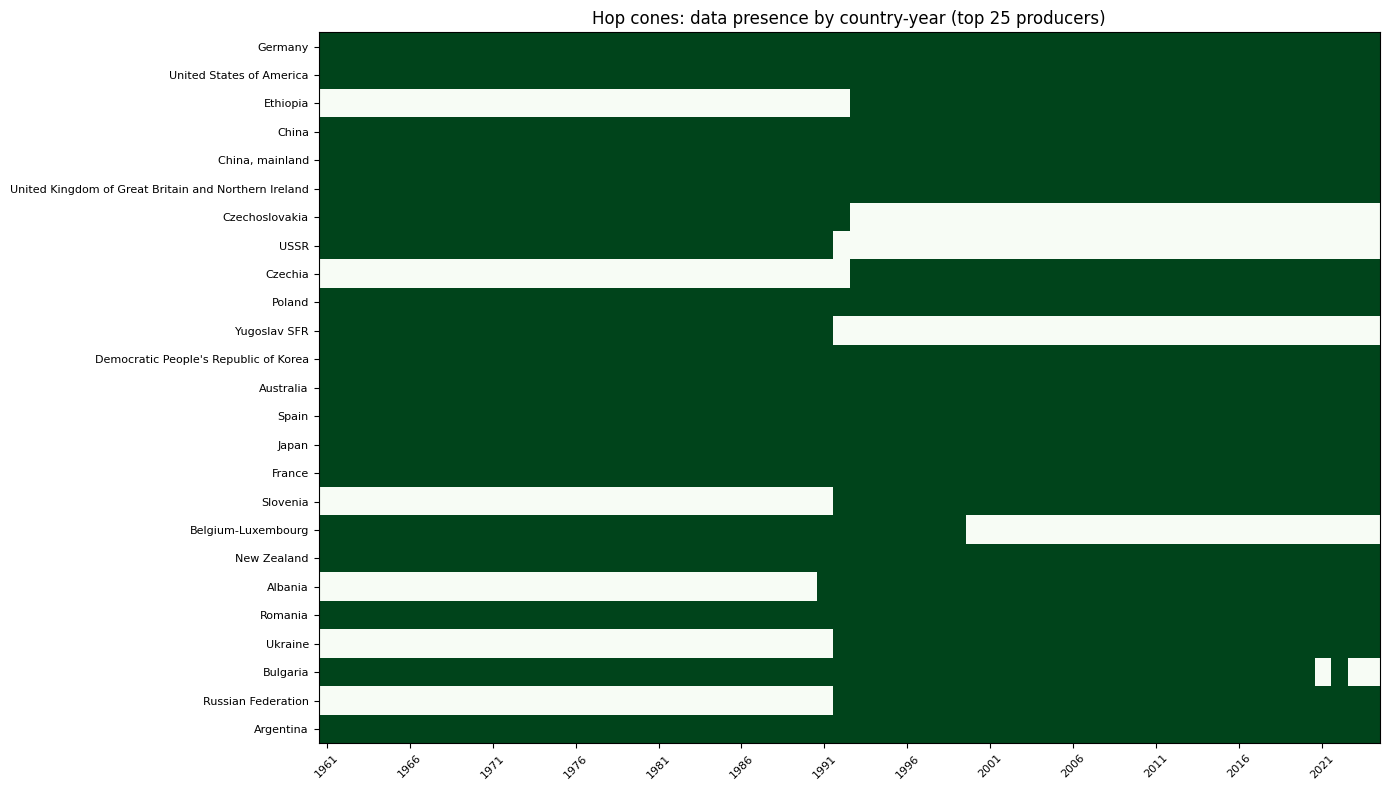

In [ ]:
# Coverage heatmap for hops (change crop_name to inspect others)
crop_name = [k for k in ITEM_CODES if 'Hop' in k][0]
h = prod[prod['crop'] == crop_name]
pivot = h.pivot_table(index='Area', columns='Year', values='Value', aggfunc='size').notna()
top_producers = h.groupby('Area')['Value'].sum().nlargest(25).index
fig, ax = plt.subplots(figsize=(14, 8))
ax.imshow(pivot.loc[[a for a in top_producers if a in pivot.index]], aspect='auto', cmap='Greens')
ax.set_yticks(range(len([a for a in top_producers if a in pivot.index])))
ax.set_yticklabels([a for a in top_producers if a in pivot.index], fontsize=8)
xt = range(0, pivot.shape[1], 5)
ax.set_xticks(list(xt)); ax.set_xticklabels(pivot.columns[list(xt)], rotation=45, fontsize=8)
ax.set_title(f'{crop_name}: data presence by country-year (top 25 producers)')
plt.tight_layout(); plt.show()

## Section 5: Completeness check 2, quality flags
Presence is not quality. FAOSTAT flags: **A** = official figure, **E** = estimated, **I** = imputed, **M** = missing.
If hops turns out to be 60% imputed, our "depth of analysis" claim weakens and we lean harder on barley and apples.
This table is the single most important pre-kickoff output.

In [ ]:
flag_col = [c for c in prod.columns if 'Flag' in c][0]
flag_pct = (prod.groupby(['crop', flag_col]).size()
    .groupby(level=0).apply(lambda s: round(100 * s / s.sum(), 1))
    .unstack(fill_value=0))
print(flag_pct.to_string())
print('\nVerdict guide: A (official) share above ~50% for recent years = solid. Heavy I (imputed) = flag it in our methods slide, judges respect honesty about data limits.')

Flag                          A     E    I    M    X
crop         crop                                   
Apples       Apples        79.3  10.3  4.3  1.6  4.5
Barley       Barley        84.8   7.6  2.0  2.7  3.0
Hop cones    Hop cones     65.7  18.5  8.6  4.2  3.0
Maize (corn) Maize (corn)  80.8   9.4  3.5  1.2  5.0

Verdict guide: A (official) share above ~50% for recent years = solid. Heavy I (imputed) = flag it in our methods slide, judges respect honesty about data limits.


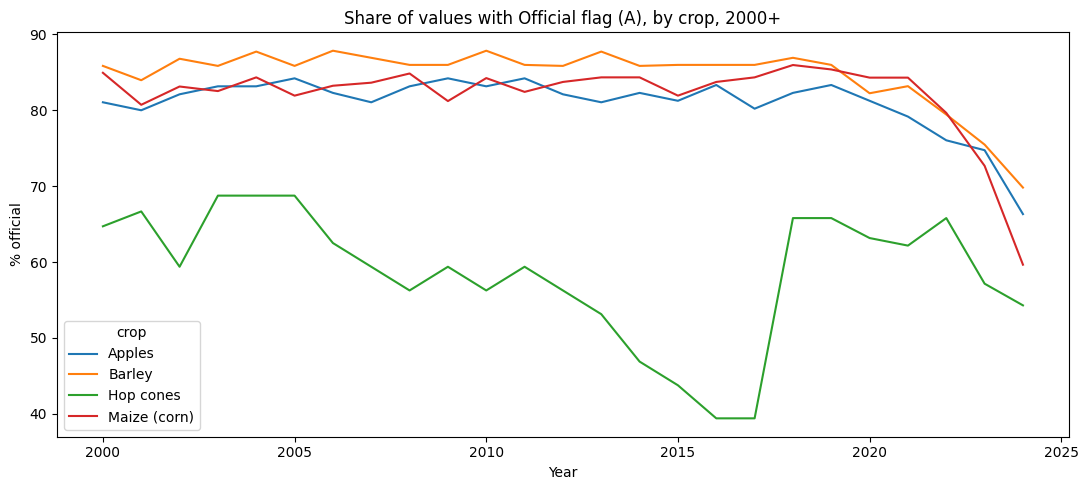

In [ ]:
# Flag quality over time: has official reporting improved or decayed?
recent = prod[prod['Year'] >= 2000]
official_share = (recent.assign(is_official=recent[flag_col] == 'A')
    .groupby(['crop', 'Year'])['is_official'].mean().mul(100).unstack(level=0))
official_share.plot(figsize=(11, 5), title='Share of values with Official flag (A), by crop, 2000+')
plt.ylabel('% official'); plt.tight_layout(); plt.show()

## Section 6: Concentration, our core macro claim
"Production of beverage-critical crops is concentrated in a handful of countries." Test it: top-5 country share of world production, latest complete year. If hops is not >60% concentrated, the framing needs a rethink before kickoff.

In [ ]:
latest = prod.groupby('crop')['Year'].transform('max') - 1  # latest full year
recent_prod = prod[prod['Year'] == latest]
for crop_name in ITEM_CODES:
    c = recent_prod[recent_prod['crop'] == crop_name]
    world = c['Value'].sum()
    top5 = c.nlargest(5, 'Value')[['Area', 'Value']]
    share = 100 * top5['Value'].sum() / world if world else float('nan')
    print(f"\n{crop_name} - top 5 share of world production: {share:.1f}%")
    print(top5.assign(pct=lambda d: round(100 * d['Value'] / world, 1)).to_string(index=False))


Barley - top 5 share of world production: 44.4%
              Area      Value  pct
Russian Federation 20500000.0 14.3
            France 12143490.0  8.5
           Germany 10999900.0  7.7
         Australia 10961886.0  7.6
          TÃ¼rkiye  9200000.0  6.4

Maize (corn) - top 5 share of world production: 74.7%
                    Area       Value  pct
United States of America 389694460.0 25.5
                   China 289065681.0 18.9
         China, mainland 288842300.0 18.9
                  Brazil 131949711.0  8.6
               Argentina  41409448.0  2.7

Apples - top 5 share of world production: 76.8%
                    Area      Value  pct
                   China 49602889.0 33.7
         China, mainland 49601700.0 33.7
United States of America  5203840.0  3.5
                TÃ¼rkiye  4602517.0  3.1
                  Poland  3892700.0  2.6

Hop cones - top 5 share of world production: 85.8%
                    Area    Value  pct
United States of America 47190.00 27.4
         

## Section 7: Trade matrix taste test (TM domain)
The Detailed Trade Matrix is the biggest FAOSTAT domain and the likeliest to strain Colab memory.
We pull ONE crop-year to measure size before committing. If a single year of barley is manageable, the trade-dependency map is feasible.

In [ ]:
# Trade matrix taste test, bulk-first (API fallback inside)
# Bulk TM is large (~500 MB zip). We only need barley, so we stream-filter to keep Colab memory sane.
TM_BULK = 'https://bulks-faostat.fao.org/production/Trade_DetailedTradeMatrix_E_All_Data_(Normalized).zip'
try:
    import urllib.request, zipfile, os
    if not os.path.exists('tm_bulk.zip'):
        print('Downloading TM bulk (~500 MB, 5-10 min)...')
        urllib.request.urlretrieve(TM_BULK, 'tm_bulk.zip')
    with zipfile.ZipFile('tm_bulk.zip') as z:
        csv_name = [n for n in z.namelist() if n.endswith('.csv') and 'Normalized' in n][0]
        chunks = []
        for chunk in pd.read_csv(z.open(csv_name), encoding='latin-1', low_memory=False, chunksize=1_000_000):
            chunks.append(chunk[chunk['Item Code'] == 44])  # Barley
        tm = pd.concat(chunks, ignore_index=True)
    print(f'Barley trade rows (all years, all partners): {len(tm):,}')
    print(tm[tm['Year'] == tm['Year'].max()].nlargest(10, 'Value')[['Reporter Countries','Partner Countries','Element','Value','Unit']].to_string(index=False))
except Exception as e:
    print(f'Bulk TM failed ({e}).')
    print('Plan B: download manually from https://www.fao.org/faostat/en/#data/TM (Bulk Downloads button, right panel), upload to Colab, rerun.')

Barley trade rows (all years, all partners): 104,274
Reporter Countries  Partner Countries         Element      Value     Unit
   China, mainland          Australia Import quantity 5250714.00        t
         Australia    China, mainland Export quantity 4831298.12        t
   China, mainland             France Import quantity 2132749.20        t
      Saudi Arabia Russian Federation Import quantity 2039868.45        t
   China, mainland             Canada Import quantity 1912791.60        t
            France    China, mainland Export quantity 1870877.13        t
            Canada    China, mainland Export quantity 1830868.00        t
   China, mainland          Argentina Import quantity 1672858.00        t
         Argentina    China, mainland Export quantity 1527308.00        t
   China, mainland          Australia    Import value 1462017.00 1000 USD


## Section 8: Water stress without leaving FAOSTAT
Bonus finding for the team: FAOSTAT's **SDGB** domain carries SDG indicator 6.4.2 (water stress) by country,
so Layer 1 may not need a separate AQUASTAT download at all. One source, one join key, less risk.

In [5]:
# Water stress (SDG 6.4.2), bulk-first
SDG_BULK = 'https://bulks-faostat.fao.org/production/Environment_Sustainability_E_All_Data_(Normalized).zip'
try:
    sdg_items = faostat.get_par_df('SDGB', 'item')  # API attempt first (tiny call)
    water = sdg_items[sdg_items['label'].str.contains('water stress|6.4', case=False, na=False)]
    print(water[['label','value']].to_string(index=False))
except Exception:
    print('API locked. Bulk route: on https://www.fao.org/faostat/en/#data/SDGB use the Bulk Downloads button,')
    print('or try the direct file (name may vary):', SDG_BULK)
    print('Then filter Item/Element containing "water stress" (SDG 6.4.2) and join to production data on Area Code.')

API locked. Bulk route: on https://www.fao.org/faostat/en/#data/SDGB use the Bulk Downloads button,
or try the direct file (name may vary): https://bulks-faostat.fao.org/production/Environment_Sustainability_E_All_Data_(Normalized).zip
Then filter Item/Element containing "water stress" (SDG 6.4.2) and join to production data on Area Code.


## Section 9: Auto-generated verdict for the team
Run everything above, then this cell writes the summary to share in chat.

| Question | Where answered | Decision it drives |
|---|---|---|
| Does hops have enough real (non-imputed) data? | Sections 4-5 | Keep hops or pivot to barley/apples as lead crop |
| Is production actually concentrated? | Section 6 | Core claim of the video holds or not |
| Can Colab handle the trade matrix? | Section 7 | Trade-dependency map in or out of scope |
| Is water stress available inside FAOSTAT? | Section 8 | One data source instead of two |

**Verification note:** cross-check any surprising number against the FAOSTAT web interface at
https://www.fao.org/faostat/en/#data/QCL (same data, point-and-click) before repeating it in a team call.

In [ ]:
print('=' * 60)
print('PRE-KICKOFF DATA VERDICT (paste into team chat)')
print('=' * 60)
print(summary.to_string())
print()
print('Flag quality (% of rows by flag):')
print(flag_pct.to_string())
print()
print('Generated from FAOSTAT BULK LOAD,', pd.Timestamp.now().strftime('%Y-%m-%d'))

PRE-KICKOFF DATA VERDICT (paste into team chat)
              n_countries  first_year  last_year  n_rows  pct_null
crop                                                              
Apples                102        1961       2024    5341       1.6
Barley                114        1961       2024    6047       2.7
Hop cones              48        1961       2024    1979       4.2
Maize (corn)          183        1961       2024    9923       1.2

Flag quality (% of rows by flag):
Flag                          A     E    I    M    X
crop         crop                                   
Apples       Apples        79.3  10.3  4.3  1.6  4.5
Barley       Barley        84.8   7.6  2.0  2.7  3.0
Hop cones    Hop cones     65.7  18.5  8.6  4.2  3.0
Maize (corn) Maize (corn)  80.8   9.4  3.5  1.2  5.0

Generated from FAOSTAT BULK LOAD, 2026-08-19


## Section 10: Sources Log (team rule: log every dataset the day you touch it)
The Datathon rules require all data sources cited in the presentation. This table IS our citation slide; keep it current and week 4 costs nothing.

| Dataset | Publisher | URL | Date pulled | Who | Used for |
|---|---|---|---|---|---|
| Production: Crops and Livestock (QCL), bulk normalized | FAO / FAOSTAT | https://bulks-faostat.fao.org/production/Production_Crops_Livestock_E_All_Data_(Normalized).zip | 2026-08-14 | Heidi | Completeness EDA, concentration metrics |
| (add next dataset here) | | | | | |

Format for new rows: dataset name, publisher, exact URL, date pulled, your name, one phrase on what it feeds.